In [5]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suppress all TF warnings (1=info, 2=warning, 3=error)

import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)

import tensorflow as tf
print(f"TensorFlow version: {tf.__version__}, GPU: {len(tf.config.list_physical_devices('GPU')) > 0}")
tf.get_logger().setLevel('ERROR')  # Set logger to ERROR only

SEED = 42
BATCH_SIZE = 32
HEIGHT, WIDTH = 224, 224

TRAIN_DIR = os.path.join(os.getcwd(), 'data', 'chest_xray', 'train')
VALIDATION_DIR = os.path.join(os.getcwd(), 'data', 'chest_xray', 'test')

TensorFlow version: 2.10.1, GPU: True


# Visualzing dataset

C:\Users\zabeeh\PycharmProjects\DeepLearning\CompleteProjects\PneumoniaDetection\data\chest_xray\train\NORMAL\IM-0115-0001.jpeg
tf ==  shape (1858, 2090, 1) and dtype <dtype: 'uint8'>
cv2 == shape (1858, 2090, 3) and dtype  uint8 
------------------------------------------------------------
cv2 img resized shape (224, 224, 3) and dtype  uint8 


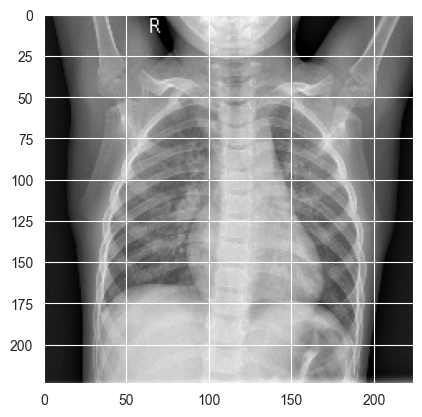

In [6]:
import os, cv2
import glob
import matplotlib.pyplot as plt

path = glob.glob(os.path.join(TRAIN_DIR, '**', '*.jpeg'), recursive=True)[0]
print(path)

img = tf.image.decode_image(tf.io.read_file(path))
print("tf ==  shape {} and dtype {}".format(img.shape, img.dtype))

img = cv2.imread(str(path))
print("cv2 == shape {} and dtype  {} ".format(img.shape, img.dtype))
print("-" * 60)

img_resized = cv2.resize(img, (HEIGHT, WIDTH))
plt.imshow(img_resized)
print("cv2 img resized shape {} and dtype  {} ".format(img_resized.shape, img_resized.dtype))

plt.show()

In [7]:
from tensorflow.keras import layers
import numpy as np

training_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, shuffle=True, seed=SEED, image_size=(HEIGHT, WIDTH),
    color_mode='grayscale',       #converts chaneel =1
    batch_size=BATCH_SIZE, label_mode='int')

validation_ds = tf.keras.utils.image_dataset_from_directory(
    VALIDATION_DIR, shuffle=False, seed=SEED, image_size=(HEIGHT, WIDTH),
    color_mode='grayscale',
    batch_size=BATCH_SIZE, label_mode='int')

for images, labels in training_ds.take(1):
    print(f"training_ds Batch No. 1 image shape : {images.shape} -- labels shape : {labels.shape}")

for images, labels in validation_ds.take(1):
    print(f"validation_ds Batch No. 1 image shape : {images.shape} -- labels shape : {labels.shape}")
print("-" * 60)

class_names = validation_ds.class_names
print("class names in dataset are ", class_names)

data_augmentation = tf.keras.Sequential([layers.Rescaling(1. / 255),  # Scale to [0,1]
                                         layers.RandomFlip("horizontal"),  # Random horizontal flip
                                         layers.RandomRotation(0.05),  # Small rotation
                                         layers.RandomZoom(0.1)  # Random zoom
                                         ])

rescale_only = tf.keras.Sequential([layers.Rescaling(1. / 255)])

AUTOTUNE = tf.data.AUTOTUNE

training_ds = training_ds.shuffle(1000)
training_ds = training_ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
training_ds = training_ds.prefetch(AUTOTUNE)

validation_ds = validation_ds.map(lambda x, y: (rescale_only(x), y), num_parallel_calls=AUTOTUNE)
val_ds = validation_ds.cache().prefetch(AUTOTUNE)

train_labels = np.concatenate([y.numpy() for _, y in training_ds])
val_labels = np.concatenate([y.numpy() for _, y in validation_ds])

print("Train distribution:", np.bincount(train_labels))
print("Val distribution:", np.bincount(val_labels))

Found 5232 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
training_ds Batch No. 1 image shape : (32, 224, 224, 1) -- labels shape : (32,)
validation_ds Batch No. 1 image shape : (32, 224, 224, 1) -- labels shape : (32,)
------------------------------------------------------------
class names in dataset are  ['NORMAL', 'PNEUMONIA']
Train distribution: [1349 3883]
Val distribution: [234 390]


### class imbalance handling

In [8]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

y_train = np.concatenate([y.numpy() for _, y in training_ds])

class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)

class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

Class weights: {0: 1.939214232765011, 1: 0.6737058975019315}


In [9]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, Flatten, GlobalAveragePooling2D, \
    Dense, Dropout, MaxPool2D
from tensorflow.keras import regularizers

input_layer = Input(shape=(HEIGHT, WIDTH, 1))

x = Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal',kernel_regularizer=regularizers.l2(0.01))(input_layer)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPool2D()(x)

x = Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal',kernel_regularizer=regularizers.l2(0.01))(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPool2D()(x)

x = Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal',kernel_regularizer=regularizers.l2(0.01))(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)

x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(1, activation='sigmoid')(x)

model = Model(input_layer, output)

model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 1)]     0         
                                                                 
 conv2d (Conv2D)             (None, 224, 224, 64)      640       
                                                                 
 batch_normalization (BatchN  (None, 224, 224, 64)     256       
 ormalization)                                                   
                                                                 
 activation (Activation)     (None, 224, 224, 64)      0         
                                                                 
 max_pooling2d (MaxPooling2D  (None, 112, 112, 64)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 112, 112, 64)      36928 

In [10]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=["accuracy", 'AUC'])

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5, min_lr=1e-6, verbose=1, cooldown=3),
    ModelCheckpoint('pneumonia_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

history = model.fit(training_ds, validation_data=validation_ds, epochs=25,
                    # batch_size=64,    # already what is given in tf method
                    #    class_weight=class_weights,
                    callbacks=callbacks, verbose=1)

Epoch 1/25
164/164 [==============================] - ETA: 0s - loss: 3.9496 - accuracy: 0.7773 - auc: 0.8204
Epoch 1: val_accuracy improved from -inf to 0.62500, saving model to pneumonia_model.keras
164/164 [==============================] - 31s 115ms/step - loss: 3.9496 - accuracy: 0.7773 - auc: 0.8204 - val_loss: 3.9705 - val_accuracy: 0.6250 - val_auc: 0.8287 - lr: 1.0000e-04
Epoch 2/25
164/164 [==============================] - ETA: 0s - loss: 3.1359 - accuracy: 0.8492 - auc: 0.9189
Epoch 2: val_accuracy did not improve from 0.62500
164/164 [==============================] - 21s 113ms/step - loss: 3.1359 - accuracy: 0.8492 - auc: 0.9189 - val_loss: 3.9443 - val_accuracy: 0.6250 - val_auc: 0.8212 - lr: 1.0000e-04
Epoch 3/25
164/164 [==============================] - ETA: 0s - loss: 2.5981 - accuracy: 0.8836 - auc: 0.9400
Epoch 3: val_accuracy did not improve from 0.62500
164/164 [==============================] - 21s 112ms/step - loss: 2.5981 - accuracy: 0.8836 - auc: 0.9400 - val

In [11]:
model.evaluate(validation_ds)

from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in validation_ds:
    probs = model.predict(images, verbose=0)
    preds = (probs > 0.35).astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(preds.ravel())

classes = ["NORMAL", "PNEUMONIA"]

print(classification_report(y_true, y_pred, target_names=classes))

20/20 [==============================] - 1s 29ms/step - loss: 1.0575 - accuracy: 0.8141 - auc: 0.8923
              precision    recall  f1-score   support

      NORMAL       0.79      0.70      0.74       234
   PNEUMONIA       0.83      0.89      0.86       390

    accuracy                           0.82       624
   macro avg       0.81      0.79      0.80       624
weighted avg       0.82      0.82      0.81       624



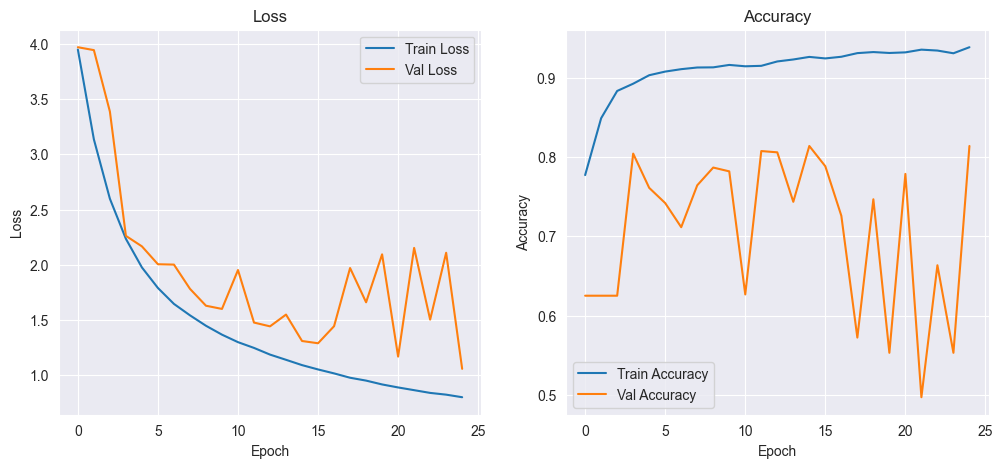

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [18]:
# Actual Class weights: {0: 1.939214232765011, 1: 0.6737058975019315}
#  give more weight to pneumenia
medical_weights = {
    0: class_weights[0] * 0.8,  # Reduce normal further
    1: class_weights[1] * 1.5    # Boost pneumonia
}

print(medical_weights)

{0: 1.5513713862120089, 1: 1.0105588462528974}


#  WITH CLASS IMBALANCE HANDLING

In [19]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=["accuracy", 'AUC'])

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5, min_lr=1e-6, verbose=1, cooldown=3),
    ModelCheckpoint('pneumonia_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

history_weighted = model.fit(training_ds, validation_data=validation_ds, epochs=25,
                             class_weight=medical_weights,
                             callbacks=callbacks, verbose=1)

Epoch 1/25
164/164 [==============================] - ETA: 0s - loss: 0.6979 - accuracy: 0.9364 - auc: 0.9793
Epoch 1: val_accuracy improved from -inf to 0.65224, saving model to pneumonia_model.keras
164/164 [==============================] - 23s 117ms/step - loss: 0.6979 - accuracy: 0.9364 - auc: 0.9793 - val_loss: 1.4706 - val_accuracy: 0.6522 - val_auc: 0.8983 - lr: 1.0000e-04
Epoch 2/25
164/164 [==============================] - ETA: 0s - loss: 0.6846 - accuracy: 0.9413 - auc: 0.9795
Epoch 2: val_accuracy improved from 0.65224 to 0.80929, saving model to pneumonia_model.keras
164/164 [==============================] - 22s 117ms/step - loss: 0.6846 - accuracy: 0.9413 - auc: 0.9795 - val_loss: 0.9656 - val_accuracy: 0.8093 - val_auc: 0.8857 - lr: 1.0000e-04
Epoch 3/25
164/164 [==============================] - ETA: 0s - loss: 0.6741 - accuracy: 0.9394 - auc: 0.9801
Epoch 3: val_accuracy improved from 0.80929 to 0.82051, saving model to pneumonia_model.keras
164/164 [================

In [20]:
model.evaluate(validation_ds)

from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in validation_ds:
    probs = model.predict(images, verbose=0)
    preds = (probs > 0.3).astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(preds.ravel())

classes = ["NORMAL", "PNEUMONIA"]

print(classification_report(y_true, y_pred, target_names=classes))

20/20 [==============================] - 1s 30ms/step - loss: 0.7786 - accuracy: 0.8590 - auc: 0.9284
              precision    recall  f1-score   support

      NORMAL       0.90      0.71      0.79       234
   PNEUMONIA       0.84      0.95      0.89       390

    accuracy                           0.86       624
   macro avg       0.87      0.83      0.84       624
weighted avg       0.86      0.86      0.85       624



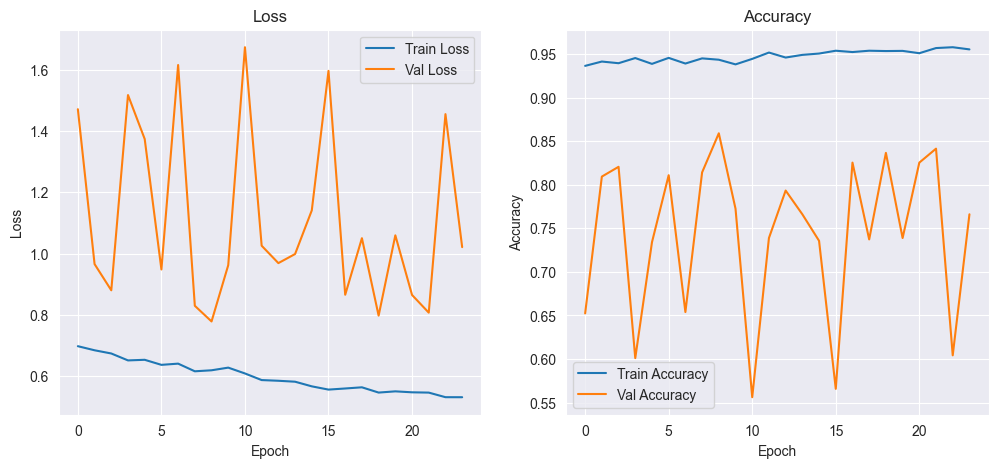

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_weighted.history['loss'], label='Train Loss')
plt.plot(history_weighted.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_weighted.history['accuracy'], label='Train Accuracy')
plt.plot(history_weighted.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()